![Health-Informatics: A Python Tutorial](../../Image/chapter-banner.png)


# Module 8: Data Quality and Validation



**Health Informatics in Python** · Part II: Interoperability & Data Engineering · Module 8 of 16

---



Analytics is only as trustworthy as the data underneath it. Health data is
notoriously messy — missing labs, impossible values, broken links between tables.
This module builds a systematic **data-quality (DQ) assessment** using the widely
adopted **Kahn framework**: *conformance, completeness, plausibility*.


## Learning objectives

By the end of this module you will be able to:

1. Apply the **Kahn DQ framework** - conformance, completeness, plausibility.
2. Write **automated checks** for data types, value domains, and referential integrity.
3. **Profile** a dataset's missingness and distributions.
4. Flag outliers with simple **anomaly detection**.
5. Assemble a reusable **DQ scorecard** and record **provenance**.


## Dataset

The synthetic EHR - but we deliberately **inject a few defects** (an impossible age,
a broken foreign key, an out-of-range lab, a missing value) so the checks have
something to catch. This mirrors what real DQ tooling faces.


In [1]:
# --- Self-contained synthetic EHR generator (identical to Part I) ---
# This is the SAME generator from Module 1. We rebuild the fake hospital database
# here so this notebook can run on its own. Nothing here is a real patient.
import numpy as np
import pandas as pd

# This function generates a synthetic electronic health record (EHR) dataset.
# It creates mock tables for patients, encounters, observations, conditions, and medications,
# all with plausible structure, but not referencing any real patients or requiring external data.
def make_synthetic_ehr(n_patients=200, seed=42):
    """
    Generate a small, internally-consistent synthetic EHR dataset.
    Returns a dict of linked DataFrames: patients, encounters, observations,
    conditions, and medications. This is for illustrative, educational use.
    """
    rng = np.random.default_rng(seed)  # same seed => same fake people every run

    # --- patients table ---
    # Create a DataFrame with n_patients patients, each with a name, sex, age, and birth year.
    first = ["Ava","Liam","Noah","Mia","Zoe","Omar","Ivan","Sara","Leo","Nina",
             "Ruth","Kai","Yara","Theo","Ida","Sam","Ana","Eli","Rex","Uma"]
    last  = ["Khan","Ortiz","Chen","Diaz","Patel","Ali","Brown","Nash","Reed","Vega",
             "Cole","Frost","Grant","Hale","Iqbal","Jain","Kerr","Lund","Mora","Park"]
    sexes = rng.choice(["male", "female"], size=n_patients, p=[0.49, 0.51])
    ages  = rng.integers(18, 90, size=n_patients)
    # Columns:
    #   patient_id  — unique ID, e.g. "P1000", "P1001"
    #   given_name / family_name — randomly chosen from the name lists
    #   sex, age — pre-generated arrays
    #   birth_year — derived from age, assuming the reference year 2026
    patients = pd.DataFrame({
        "patient_id": [f"P{1000+i}" for i in range(n_patients)],
        "given_name": rng.choice(first, size=n_patients),
        "family_name": rng.choice(last, size=n_patients),
        "sex": sexes,
        "age": ages,
        "birth_year": 2026 - ages,
    })

    # --- encounters table ---
    # Each patient gets 1–4 visits. Types and dates are random but internally consistent.
    #   encounter_id    — unique, zero-padded (E00001, E00002, ...)
    #   encounter_type  — ambulatory 55%, emergency 15%, inpatient 10%, wellness 20%
    #   date            — a random day in a 3-year window starting 2023-01-01
    enc_rows = []
    enc_types = ["ambulatory", "emergency", "inpatient", "wellness"]
    for pid in patients["patient_id"]:
        for _ in range(rng.integers(1, 5)):  # 1 to 4 encounters per patient
            day = rng.integers(0, 365*3)     # offset within 3 years
            enc_rows.append({
                "encounter_id": f"E{len(enc_rows)+1:05d}",
                "patient_id": pid,
                "encounter_type": rng.choice(enc_types, p=[0.55, 0.15, 0.10, 0.20]),
                "date": (pd.Timestamp("2023-01-01") + pd.Timedelta(days=int(day))).date(),
            })
    encounters = pd.DataFrame(enc_rows)

    # --- observations table ---
    # Labs and vitals attached to encounters. Each tuple is (name, unit, lo, hi).
    # A value is drawn uniformly in [lo, hi]; 70% of (encounter, measure) pairs exist
    # so the table looks sparse the way a real EHR does.
    obs_defs = [
        ("Body height", "cm", 150, 195),
        ("Body weight", "kg", 50, 110),
        ("Systolic blood pressure", "mmHg", 100, 165),
        ("Heart rate", "/min", 55, 100),
        ("Hemoglobin A1c", "%", 4.8, 9.5),
    ]
    obs_rows = []
    for _, e in encounters.iterrows():
        for name, unit, lo, hi in obs_defs:
            if rng.random() < 0.7:
                obs_rows.append({
                    "observation_id": f"O{len(obs_rows)+1:06d}",
                    "encounter_id": e["encounter_id"],
                    "patient_id": e["patient_id"],
                    "observation": name,
                    "value": round(float(rng.uniform(lo, hi)), 1),
                    "unit": unit,
                    "date": e["date"],
                })
    observations = pd.DataFrame(obs_rows)

    # --- conditions table ---
    # Each patient is assigned 0–3 unique diagnoses from a small pool.
    cond_pool = ["Essential hypertension", "Type 2 diabetes mellitus", "Asthma",
                 "Acute bronchitis", "Major depressive disorder", "Osteoarthritis",
                 "Chronic kidney disease", "Anemia"]
    cond_rows = []
    for pid in patients["patient_id"]:
        for c in rng.choice(cond_pool, size=rng.integers(0, 4), replace=False):
            cond_rows.append({
                "condition_id": f"C{len(cond_rows)+1:05d}",
                "patient_id": pid,
                "condition": c,
            })
    conditions = pd.DataFrame(cond_rows)

    # --- medications table ---
    # Same pattern as conditions: 0–3 unique drugs per patient.
    med_pool = ["Lisinopril", "Metformin", "Albuterol", "Atorvastatin",
                "Sertraline", "Amoxicillin", "Ibuprofen", "Hydrochlorothiazide"]
    med_rows = []
    for pid in patients["patient_id"]:
        for m in rng.choice(med_pool, size=rng.integers(0, 4), replace=False):
            med_rows.append({
                "medication_id": f"M{len(med_rows)+1:05d}",
                "patient_id": pid,
                "medication": m,
            })
    medications = pd.DataFrame(med_rows)

    return {
        "patients": patients,
        "encounters": encounters,
        "observations": observations,
        "conditions": conditions,
        "medications": medications,
    }

# Generate the five linked tables. Each notebook in this series starts from here.
ehr = make_synthetic_ehr()
print("Tables:", ", ".join(f"{k} ({len(v)} rows)" for k, v in ehr.items()))


Tables: patients (200 rows), encounters (511 rows), observations (1804 rows), conditions (304 rows), medications (276 rows)


In [2]:
# Inject controlled defects into COPIES of the tables so the original `ehr`
# dict stays clean. Real DQ tooling is tested the same way: you need known
# bad rows to confirm the checks actually fire.
#
# The five defects cover the three Kahn dimensions we will check:
#   age = 210          → plausibility (impossible age)
#   sex = "unknown"    → conformance / value-domain (not in {male, female})
#   value = 480        → plausibility (impossible systolic BP)
#   value = None       → completeness (missing lab)
#   patient_id = P9999 → conformance / relational (broken foreign key)
patients = ehr["patients"].copy()
observations = ehr["observations"].copy()

patients.loc[0, "age"] = 210                 # implausible age
patients.loc[1, "sex"] = "unknown"           # nonconformant category
observations.loc[5, "value"] = 480           # impossible systolic BP
observations.loc[8, "value"] = None          # missing value
observations.loc[3, "patient_id"] = "P9999"  # broken referential link

print("Injected 5 defects across patients & observations for the checks to find.")


Injected 5 defects across patients & observations for the checks to find.


## 8.1 Conformance - does the data match its expected structure?

This section introduces the concept of "conformance" in data quality checks.
Conformance checks ensure that:
  - Values are of the correct data type (e.g., strings, numbers).
  - Values fall within a specified, allowed set (the value domain; e.g., sex must be either "male" or "female").
  - Relationships between tables are valid and intact (relational integrity; e.g., every patient_id referenced in an observation should exist in the patients table).
These checks are generally broken down into three subcategories:
  1. Value type - do data values have the expected type?
  2. Value domain - are data values from the allowed set?
  3. Relational - do references across tables (like foreign keys) point to real rows?


In [3]:
# Conformance asks: are values the RIGHT TYPE, in the ALLOWED DOMAIN, and are
# RELATIONSHIPS intact? We implement two of those sub-checks here.
#
# Each issue is a tuple:
#   (dimension, table, column, row-id, bad-value)
# so a scorecard later can group them without parsing free text.
import pandas as pd
import numpy as np
def check_conformance(patients, observations):
    issues = []

    # Value-domain: sex must be in the allowed set {male, female}.
    # ~ flips the boolean mask, so we keep rows whose sex is NOT in that set.
    bad_sex = patients[~patients["sex"].isin(["male", "female"])]
    for _, r in bad_sex.iterrows():
        issues.append(("conformance/value-domain", "patients", "sex",
                       r["patient_id"], r["sex"]))

    # Relational (referential integrity): every observations.patient_id must
    # exist in patients. An orphan row is a broken link — the lab has no owner.
    valid_ids = set(patients["patient_id"])
    orphans = observations[~observations["patient_id"].isin(valid_ids)]
    for _, r in orphans.iterrows():
        issues.append(("conformance/relational", "observations", "patient_id",
                       r["observation_id"], r["patient_id"]))
    return issues

conf_issues = check_conformance(patients, observations)
for i in conf_issues:
    print(i)


('conformance/value-domain', 'patients', 'sex', 'P1001', 'unknown')
('conformance/relational', 'observations', 'patient_id', 'O000004', 'P9999')


Explain code

## 8.2 Completeness - is expected data present?

Completeness refers to whether all the expected or required data is present in the dataset.
For example, if we collect lab results, are there any missing values for those lab tests?
Checking completeness helps identify missing or incomplete records that could impact analysis or decisions.

In [4]:
# Completeness asks: is expected data PRESENT?
# We count missing observation values overall, then break the rate down by
# observation type (A1c vs heart rate vs ...) so you can see which measure
# is holey — a missing A1c is a different operational problem than a missing height.
def check_completeness(observations):
    miss = observations["value"].isna().sum()          # how many NaN values
    pct = 100 * miss / len(observations)               # as a percent of all rows

    # Group by observation name and take the mean of a True/False missing flag.
    # mean() of booleans is the proportion missing; mul(100) turns it into %.
    profile = (
        observations.assign(missing=observations["value"].isna())
        .groupby("observation")["missing"].mean()
        .mul(100).round(1)
        .rename("pct_missing")
        .reset_index()
    )
    return miss, pct, profile

miss_n, miss_pct, miss_profile = check_completeness(observations)
print(f"Missing observation values: {miss_n} ({miss_pct:.1f}%)")
print("\nMissingness by observation type:")
print(miss_profile.to_string(index=False))


Missing observation values: 1 (0.1%)

Missingness by observation type:
            observation  pct_missing
            Body height          0.0
            Body weight          0.0
             Heart rate          0.0
         Hemoglobin A1c          0.0
Systolic blood pressure          0.3


## 8.3 Plausibility - are the values believable?

Plausibility means: are the data values actually believable, not just present? 
This breaks down into two types:
- **Atemporal plausibility**: Checks if a single value seems reasonable and possible (e.g., a person's age is between 0 and 120, or a blood pressure is within human limits).
- **Temporal plausibility**: Checks if events happen in a logically correct order (e.g., a birth date must be before any medical encounter for that person, or hospital admission comes before discharge).


In [5]:
# Plausibility asks: are the values BELIEVABLE even if they have the right type?
# Atemporal = a single value in a sane range (age, lab). Temporal (exercise 1)
# would check order: birth before any encounter, admission before discharge.
#
# These bounds are coarse "could a living human have this?" ranges, not
# clinical reference ranges. Age 210 and SBP 480 should never survive.
RANGES = {
    "Systolic blood pressure": (60, 250),
    "Heart rate": (30, 220),
    "Hemoglobin A1c": (3, 20),
    "Body weight": (2, 350),
    "Body height": (30, 250),
}

def check_plausibility(patients, observations):
    issues = []

    # Atemporal: age must be in [0, 120]
    for _, r in patients[(patients["age"] < 0) | (patients["age"] > 120)].iterrows():
        issues.append(("plausibility/atemporal", "patients", "age",
                       r["patient_id"], r["age"]))

    # Atemporal: each observation value must fall in its RANGES entry.
    # dropna skips the missing row we already counted under completeness.
    # .get(..., (-inf, inf)) means "no range defined → never flag".
    for _, r in observations.dropna(subset=["value"]).iterrows():
        lo, hi = RANGES.get(r["observation"], (-np.inf, np.inf))
        if not (lo <= r["value"] <= hi):
            issues.append(("plausibility/atemporal", "observations", r["observation"],
                           r["observation_id"], r["value"]))
    return issues

plaus_issues = check_plausibility(patients, observations)
for i in plaus_issues:
    print(i)


('plausibility/atemporal', 'patients', 'age', 'P1000', 210)
('plausibility/atemporal', 'observations', 'Heart rate', 'O000006', 480.0)


### Milestone 1 - anomaly detection on a measurement distribution

In this section, we perform anomaly detection on a measurement distribution to identify data points that are statistically extreme (outliers) within the dataset, even if they are physically possible values.

Systolic BP: mean=132.9, std=19.0
Outliers (|z|>3): 0
Empty DataFrame
Columns: [observation_id, value, z]
Index: []


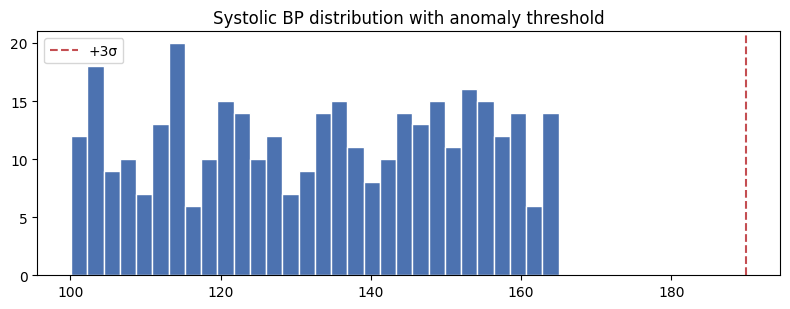

In [6]:
# Range checks catch values that are physically impossible. Anomaly detection
# catches values that are *possible* but statistically extreme in THIS dataset.
# A z-score of 3 means "3 standard deviations from the mean" — a common cutoff.
#
# z = (value - mean) / std
# |z| > 3  → flag as an outlier (the injected SBP of 480 will light up)
import matplotlib.pyplot as plt

sbp = observations[
    observations["observation"] == "Systolic blood pressure"
].dropna(subset=["value"])

mean, std = sbp["value"].mean(), sbp["value"].std()
sbp = sbp.assign(z=(sbp["value"] - mean) / std)
outliers = sbp[sbp["z"].abs() > 3]

print(f"Systolic BP: mean={mean:.1f}, std={std:.1f}")
print(f"Outliers (|z|>3): {len(outliers)}")
print(outliers[["observation_id", "value", "z"]].to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.hist(sbp["value"], bins=30, color="#4C72B0", edgecolor="white")
ax.axvline(mean + 3 * std, color="#C44E52", ls="--", label="+3σ")  # right-hand cutoff
ax.set_title("Systolic BP distribution with anomaly threshold")
ax.legend()
plt.tight_layout()
plt.show()


### Milestone 2 - assemble a DQ scorecard

In this step, we'll assemble a Data Quality (DQ) scorecard. 
The scorecard summarizes the main dimensions of data quality—conformance, completeness, and plausibility—by reporting the number of issues detected for each. 
This provides a quick overview so a data steward can easily scan and assess the overall quality of the dataset.

In [7]:
# A scorecard rolls the three Kahn dimensions into one table a steward can scan.
# n_issues = 0 → PASS, anything else → FLAG. This is the same idea as Module 6's
# validation gate, just reported instead of aborting the load.
def dq_scorecard(patients, observations):
    conf = check_conformance(patients, observations)
    plaus = check_plausibility(patients, observations)
    miss_n, miss_pct, _ = check_completeness(observations)
    rows = [
        ("Conformance",  "value-domain + referential", len(conf)),
        ("Completeness", "missing observation values", int(miss_n)),
        ("Plausibility", "range/age violations",       len(plaus)),
    ]
    card = pd.DataFrame(rows, columns=["dimension", "check", "n_issues"])
    # np.where is vectorized if-then: 0 issues → PASS, otherwise FLAG
    card["status"] = np.where(card["n_issues"] == 0, "PASS", "FLAG")
    return card

scorecard = dq_scorecard(patients, observations)
print("DATA QUALITY SCORECARD")
print(scorecard.to_string(index=False))


DATA QUALITY SCORECARD
   dimension                      check  n_issues status
 Conformance value-domain + referential         2   FLAG
Completeness missing observation values         1   FLAG
Plausibility       range/age violations         2   FLAG


## 8.4 Provenance and lineage

Data quality (DQ) findings are only useful if you can trace the origin and transformations of each data value—that is, track its **provenance**. Provenance ensures that, for any piece of data, you know **where it came from** and **what processing steps it went through**. 
At a minimum, provenance records for any processed dataset should capture:
- The original data source and how the dataset was generated (including code, parameters, and seeds, if any).
- When the data was processed.
- The size or row counts of tables after processing.
- Which data quality checks were applied.
- Any known issues or caveats (e.g., intentionally injected errors for testing).
This information makes DQ assessments trustworthy, reproducible, and auditable.


In [8]:
# A DQ result is only actionable if you can trace WHERE each value came from
# and WHAT happened to it. This dict is the minimum provenance to store with
# any processed dataset: who generated it, when, how big it was, which checks
# ran, and any known caveats (here: we injected 5 defects on purpose).
from datetime import datetime, timezone
import json

provenance = {
    "dataset": "synthetic_ehr_v1",
    "generated_by": "make_synthetic_ehr(seed=42)",  # seed makes it re-runnable
    "processed_at": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "row_counts": {k: int(len(v)) for k, v in ehr.items()},
    "dq_checks_run": ["conformance", "completeness", "plausibility"],
    "known_defects_injected": 5,
}

# json.dumps pretty-prints the dict so it can be saved beside the dataset
print(json.dumps(provenance, indent=2))


{
  "dataset": "synthetic_ehr_v1",
  "generated_by": "make_synthetic_ehr(seed=42)",
  "processed_at": "2026-08-21T00:00:35+00:00",
  "row_counts": {
    "patients": 200,
    "encounters": 511,
    "observations": 1804,
    "conditions": 304,
    "medications": 276
  },
  "dq_checks_run": [
    "conformance",
    "completeness",
    "plausibility"
  ],
  "known_defects_injected": 5
}


## Exercises

1. Add a **temporal plausibility** check: flag any encounter dated before the
   patient's `birth_year`.
2. Add a **uniqueness** conformance check ensuring `observation_id` is a primary key.
3. Turn the scorecard into a **pass/fail gate** (as in Module 6) that raises when
   any dimension exceeds a threshold you set.



## Key takeaways

- The **Kahn framework** organizes DQ into **conformance, completeness, plausibility**.
- Checks should be **automated, reusable, and produce a scorecard** — not one-off eyeballing.
- **Anomaly detection** catches values that pass type checks but are clinically absurd.
- **Provenance** makes a DQ assessment auditable and reproducible.



---
*End of Part II - Interoperability & Data Engineering*. 

*Next: Part III - Privacy, Text, and Applied Informatics*.
